## Evaluate Presidio Analyzer using the Presidio Evaluator framework

This notebook demonstrates how to evaluate a Presidio instance using the presidio-evaluator framework
Steps:
1. Load dataset from file
2. Simple dataset statistics
3. Define the AnalyzerEngine object (and its parameters)
4. Align the dataset's entities to Presidio's entities
5. Set up the Evaluator object
6. Run experiment
7. Evaluate results
8. Error analysis

For an example with a custom Presidio instance, see [notebook 5](5_Evaluate_Custom_Presidio_Analyzer.ipynb).

In [ ]:
# install presidio evaluator via pip if not yet installed

#!pip install presidio-evaluator

In [ ]:
from pathlib import Path
from pprint import pprint
from collections import Counter
from typing import List
import json

from presidio_evaluator import InputSample
from presidio_evaluator.evaluation import SpanEvaluator, ModelError, Plotter
from presidio_evaluator.experiment_tracking import get_experiment_tracker
from presidio_evaluator.models import PresidioAnalyzerWrapper
from presidio_evaluator.entity_mapping import EntityMappingHelper

from presidio_analyzer import AnalyzerEngine

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

%reload_ext autoreload
%autoreload 2

## 1. Load dataset from file

In [3]:
dataset_name = "synth_dataset_v2.json"
dataset = InputSample.read_dataset_json(Path(Path.cwd().parent, "data", dataset_name))
print(len(dataset))

tokenizing input: 100%|██████████| 1500/1500 [00:07<00:00, 207.80it/s]

1500


This dataset was auto generated. See more info here [Synthetic data generation](1_Generate_data.ipynb).

In [4]:
def get_entity_counts(dataset: List[InputSample]) -> Counter:
    """Return a dictionary with counter per entity type."""
    entity_counter = Counter()
    for sample in dataset:
        for tag in sample.tags:
            entity_counter[tag] += 1
    return entity_counter


## 2. Simple dataset statistics

In [5]:
entity_counts = get_entity_counts(dataset)
print("Count per entity:")
pprint(entity_counts.most_common(), compact=True)

print("\nMin and max number of tokens in dataset: "\
f"Min: {min([len(sample.tokens) for sample in dataset])}, "\
f"Max: {max([len(sample.tokens) for sample in dataset])}")

print(f"Min and max sentence length in dataset: " \
f"Min: {min([len(sample.full_text) for sample in dataset])}, "\
f"Max: {max([len(sample.full_text) for sample in dataset])}")

print("\nExample InputSample:")
print(dataset[0])

Count per entity:
[('O', 19626), ('STREET_ADDRESS', 3071), ('PERSON', 1369), ('GPE', 521),
 ('ORGANIZATION', 504), ('PHONE_NUMBER', 350), ('DATE_TIME', 219),
 ('TITLE', 142), ('CREDIT_CARD', 136), ('US_SSN', 80), ('AGE', 74), ('NRP', 55),
 ('ZIP_CODE', 50), ('EMAIL_ADDRESS', 49), ('DOMAIN_NAME', 37),
 ('IP_ADDRESS', 22), ('IBAN_CODE', 21), ('US_DRIVER_LICENSE', 9)]

Min and max number of tokens in dataset: Min: 3, Max: 78
Min and max sentence length in dataset: Min: 9, Max: 407

Example InputSample:
Full text: The address of Persint is 6750 Koskikatu 25 Apt. 864
Artilleros
, CO
 Uruguay 64677
Spans: [Span(type: STREET_ADDRESS, value: 6750 Koskikatu 25 Apt. 864
Artilleros
, CO
 Uruguay 64677, char_span: [26: 83]), Span(type: ORGANIZATION, value: Persint, char_span: [15: 22])]



In [6]:
print("A few examples sentences containing each entity:\n")
for entity in entity_counts.keys():
    samples = [sample for sample in dataset if entity in set(sample.tags)]
    if len(samples) > 1 and entity != "O":
        print(f"Entity: <{entity}> two example sentences:\n"
              f"\n1) {samples[0].full_text}"
              f"\n2) {samples[1].full_text}"
              f"\n------------------------------------\n")

A few examples sentences containing each entity:

Entity: <ORGANIZATION> two example sentences:

1) The address of Persint is 6750 Koskikatu 25 Apt. 864
Artilleros
, CO
 Uruguay 64677
2) The Exversion Orchestra was founded in 1977. Since then, it has grown from a volunteer community orchestra to a fully professional orchestra serving Southern Tunisia
------------------------------------

Entity: <STREET_ADDRESS> two example sentences:

1) The address of Persint is 6750 Koskikatu 25 Apt. 864
Artilleros
, CO
 Uruguay 64677
2) Billing address: Sara Schwarz
    28245 Puruntie 82 Apt. 595
   LAPPEENRANTA
    SK
    53650
------------------------------------

Entity: <PERSON> two example sentences:

1) Krisztián Szöllösy listed his top 20 songs for Entertainment Weekly and had the balls to list this song at #15. (What did he put at #1 you ask? Answer:"Tube Snake Boogie" by Szabina J Gelencsér ג€“ go figure)
2) My name is Rubija
------------------------------------

Entity: <DATE_TIME> two ex

## 3. Define the AnalyzerEngine object 
Using Presidio with default parameters (not recommended, it's used here for simplicity). For an example on customization, see [notebook 5](5_Evaluate_Custom_Presidio_Analyzer.ipynb).

**Note:** After loading Presidio, we'll need to map the dataset's entity types to Presidio's entity types in section 4, since they may use different naming conventions.

In [7]:
# Loading the vanilla Analyzer Engine, with the default NER model.
analyzer_engine = AnalyzerEngine(default_score_threshold=0.4)

pprint(f"Supported entities for English:")
pprint(analyzer_engine.get_supported_entities("en"), compact=True)

print(f"\nLoaded recognizers for English:")
pprint([rec.name for rec in analyzer_engine.registry.get_recognizers("en", all_fields=True)], compact=True)

print(f"\nLoaded NER models:")
pprint(analyzer_engine.nlp_engine.models)

'Supported entities for English:'
['MEDICAL_LICENSE', 'US_SSN', 'CRYPTO', 'NRP', 'LOCATION', 'PERSON', 'URL',
 'US_PASSPORT', 'IBAN_CODE', 'US_BANK_NUMBER', 'US_DRIVER_LICENSE',
 'IP_ADDRESS', 'EMAIL_ADDRESS', 'MAC_ADDRESS', 'DATE_TIME', 'US_ITIN',
 'PHONE_NUMBER', 'UK_NHS', 'CREDIT_CARD']

Loaded recognizers for English:
['CreditCardRecognizer', 'UsBankRecognizer', 'UsLicenseRecognizer',
 'UsItinRecognizer', 'UsPassportRecognizer', 'UsSsnRecognizer', 'NhsRecognizer',
 'CryptoRecognizer', 'DateRecognizer', 'EmailRecognizer', 'IbanRecognizer',
 'IpRecognizer', 'MedicalLicenseRecognizer', 'MacAddressRecognizer',
 'PhoneRecognizer', 'UrlRecognizer', 'SpacyRecognizer']

Loaded NER models:
[{'lang_code': 'en', 'model_name': 'en_core_web_lg'}]


## 4. Interactive Entity Mapping

**Entity mapping** translates the dataset's entity types to match the model's entity types. This is crucial because:
- Datasets and models often use different entity naming conventions
- For example: Dataset might have `STREET_ADDRESS` while Presidio uses `LOCATION`
- Proper mapping ensures accurate evaluation

The `EntityMappingHelper` automatically suggests mappings and allows manual adjustments.


In [8]:
# Auto-detect entities and create suggested mapping
helper = EntityMappingHelper(
    dataset=dataset,
    model=analyzer_engine,
    language="en"
)

# Review the mapping (optional - shows suggested mappings)
helper.review_mapping()

Dataset Entity,→ Model Entity,Samples,Confidence
⚠️ AGE,NOT MAPPED,74,0.00
⚠️ ORGANIZATION,NOT MAPPED,199,0.00
⚠️ TITLE,NOT MAPPED,92,0.00
✓ CREDIT_CARD,CREDIT_CARD,136,1.00
✓ DATE_TIME,DATE_TIME,119,1.00
✓ DOMAIN_NAME,URL,37,1.00
✓ EMAIL_ADDRESS,EMAIL_ADDRESS,49,1.00
✓ GPE,LOCATION,325,1.00
✓ IBAN_CODE,IBAN_CODE,21,1.00
✓ IP_ADDRESS,IP_ADDRESS,14,1.00


In [9]:
# Manually adjust mappings where the automatic suggestion isn't ideal
helper.set_mapping("AGE", "DATE_TIME")
helper.set_mapping("TITLE", "PERSON")
helper.set_mapping("ORGANIZATION", None)

helper.review_mapping()

# Get the final mapping and filtered dataset
entities_mapping = helper.get_mapping()
entities_to_keep = helper.get_model_entities_to_use()
dataset = helper.get_filtered_dataset()

print("\n✓ Entity mapping complete")
print(f"Mapping: {len(entities_mapping)} entities")
print(f"Evaluating: {entities_to_keep}")

✓ Mapping set: AGE → DATE_TIME
   (2 entities still unmapped)
✓ Mapping set: TITLE → PERSON
   (1 entities still unmapped)
✓ Mapping set: ORGANIZATION → None


Dataset Entity,→ Model Entity,Samples,Confidence
○ ORGANIZATION,None,199,None ✎
✓ CREDIT_CARD,CREDIT_CARD,136,1.00
✓ DATE_TIME,DATE_TIME,119,1.00
✓ DOMAIN_NAME,URL,37,1.00
✓ EMAIL_ADDRESS,EMAIL_ADDRESS,49,1.00
✓ GPE,LOCATION,325,1.00
✓ IBAN_CODE,IBAN_CODE,21,1.00
✓ IP_ADDRESS,IP_ADDRESS,14,1.00
✓ PERSON,PERSON,637,1.00
✓ PHONE_NUMBER,PHONE_NUMBER,64,1.00



✓ Entity mapping complete
Mapping: 16 entities
Evaluating: ['CREDIT_CARD', 'DATE_TIME', 'EMAIL_ADDRESS', 'IBAN_CODE', 'IP_ADDRESS', 'LOCATION', 'NRP', 'ORGANIZATION', 'PERSON', 'PHONE_NUMBER', 'URL', 'US_DRIVER_LICENSE', 'US_SSN']


## 5. Set up the Evaluator object

In [10]:
# Set up the experiment tracker to log the experiment for reproducibility
experiment = get_experiment_tracker()

# Wrap the analyzer
wrapped_analyzer = PresidioAnalyzerWrapper(
    analyzer_engine=analyzer_engine
)

# Create the evaluator object with entity mapping
evaluator = SpanEvaluator(
    model=wrapped_analyzer,
    entity_mapping=entities_mapping
)

# Track model and dataset params
params = {"dataset_name": dataset_name, 
          "model_name": evaluator.model.name}
params.update(evaluator.model.to_log())
experiment.log_parameters(params)
experiment.log_dataset_hash(dataset)
experiment.log_parameter("entity_mappings", json.dumps(entities_mapping))




--------
Entities supported by this Presidio Analyzer instance:
MEDICAL_LICENSE, US_SSN, CRYPTO, NRP, LOCATION, PERSON, URL, US_PASSPORT, IBAN_CODE, US_BANK_NUMBER, US_DRIVER_LICENSE, IP_ADDRESS, EMAIL_ADDRESS, MAC_ADDRESS, DATE_TIME, US_ITIN, PHONE_NUMBER, UK_NHS, CREDIT_CARD


/Users/omrimendels/Documents/github/presidio-research/presidio_evaluator/evaluation/base_evaluator.py:111: UserWarning: skip words not provided, using default skip words. If you want the evaluation to not use skip words, pass skip_words=[]
  warnings.warn(


## 6. Run experiment

In [11]:
%%time
## Run experiment

evaluation_results = evaluator.evaluate_all(dataset)
results = evaluator.calculate_score(evaluation_results)

# Track experiment results
experiment.log_metrics(results.to_log())
entities, confmatrix = results.to_confusion_matrix()
experiment.log_confusion_matrix(matrix=confmatrix, 
                                labels=entities)

# end experiment
experiment.end()

saving experiment data to /Users/omrimendels/Documents/github/presidio-research/notebooks/experiment_20260228-220107.json
CPU times: user 9.56 s, sys: 289 ms, total: 9.85 s
Wall time: 10.1 s


## 7. Evaluate results

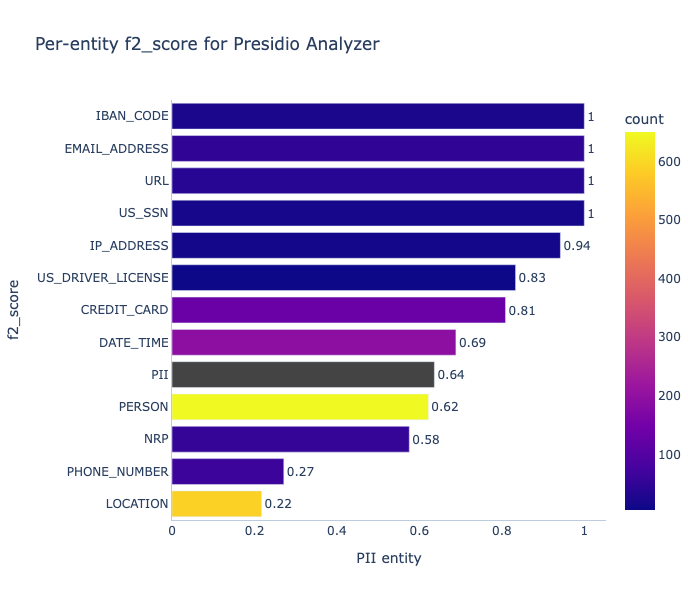

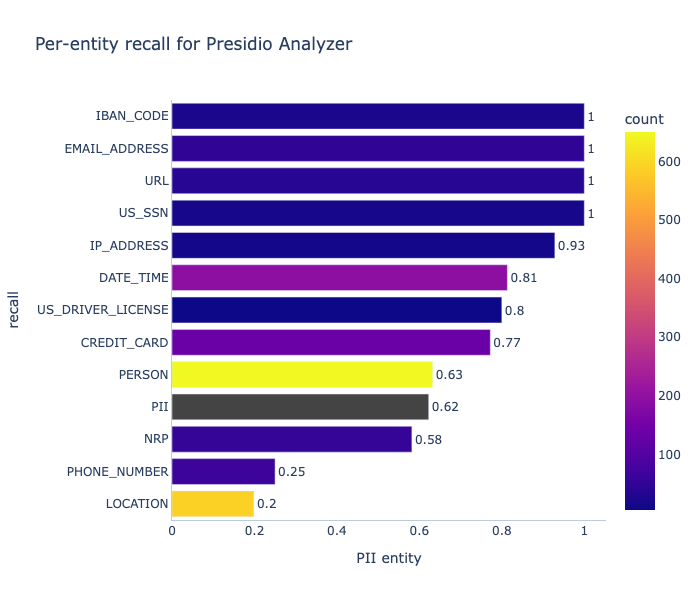

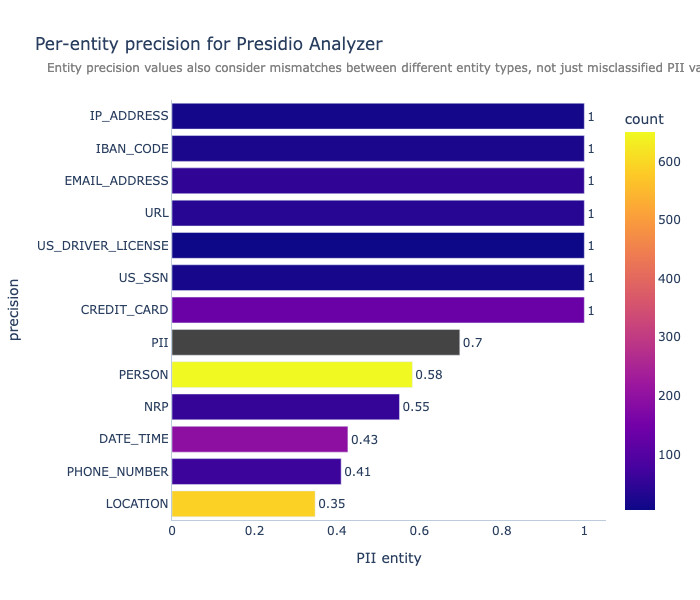

In [ ]:
# Plot output
plotter = Plotter(results=results, 
                  model_name = evaluator.model.name, 
                  display_mode="static",
                  beta = 2) 

plotter.plot_scores()

In [22]:
pprint({"PII F":results.pii_f, "PII recall": results.pii_recall, "PII precision": results.pii_precision})

{'PII F': 0.6363772008355716,
 'PII precision': 0.6980360065466449,
 'PII recall': 0.6226277372262774}


## 8. Error analysis

Now let's look into results to understand what's behind the metrics we're getting.
Note that evaluation is never perfect. Some things to consider:
1. There's often a mismatch between the annotated span and the predicted span, which isn't necessarily a mistake. For example: `<Southern France>` compared with `Southern <France>`. In the second text, the word `Southern` was not annotated/predicted as part of the entity, but that's not necessarily an error.
1. The synthetic dataset used here isn't representative of a real dataset. Consider using more realistic datasets for evaluation

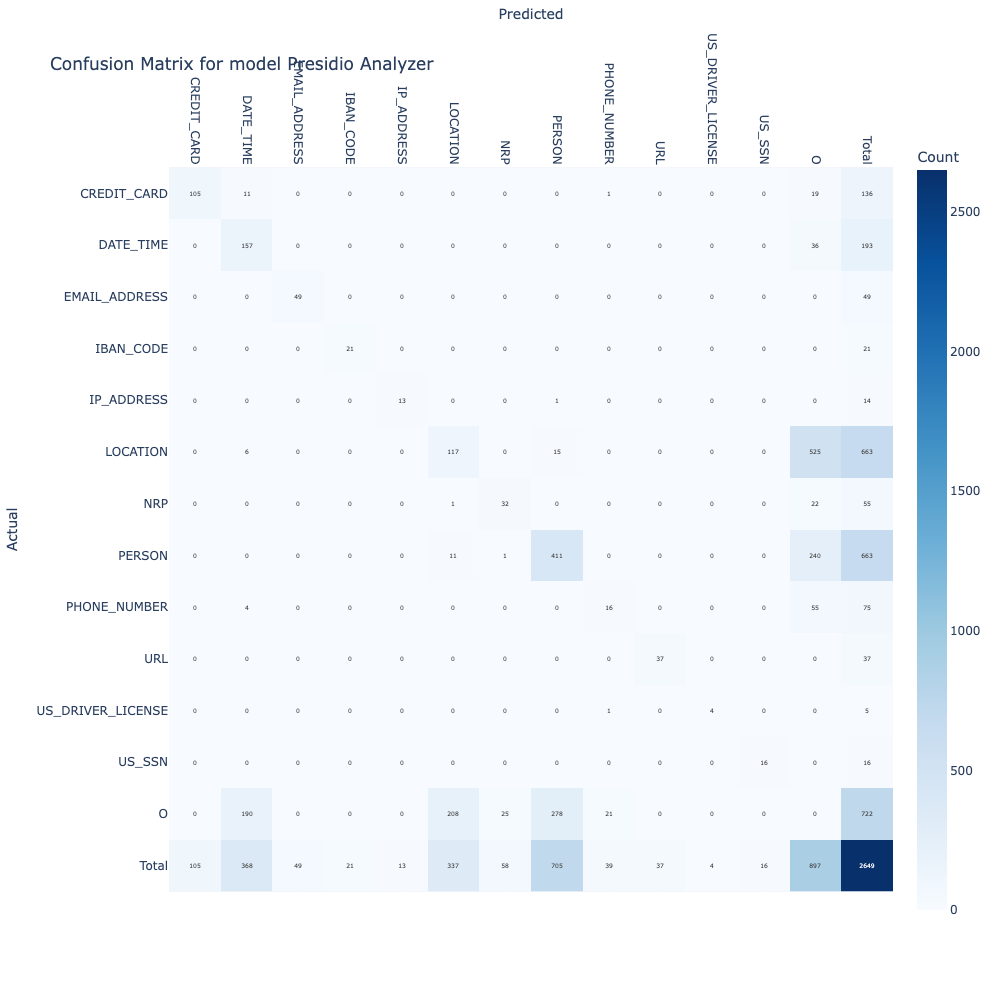

In [23]:
plotter.plot_confusion_matrix(entities=entities, confmatrix=confmatrix)

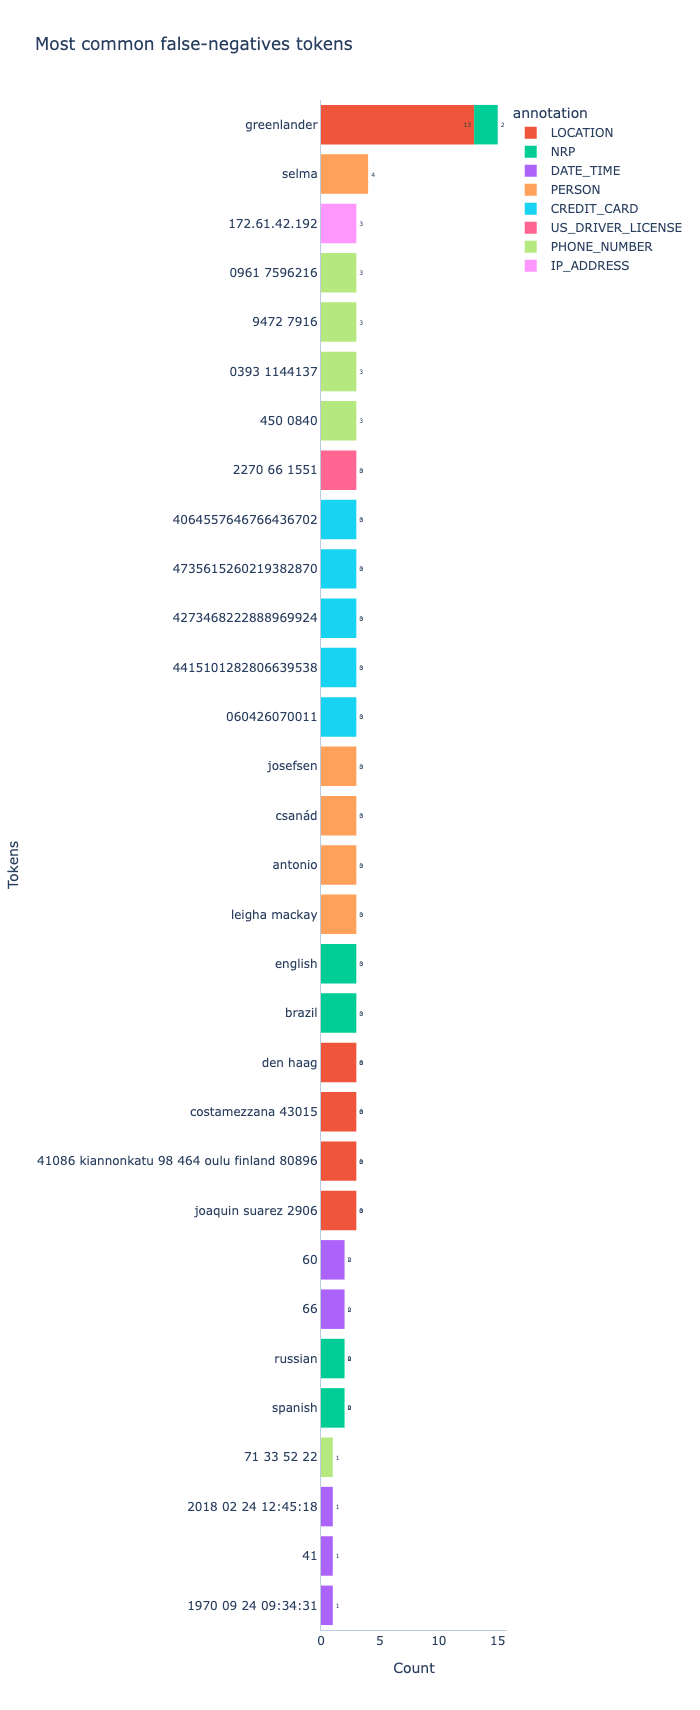

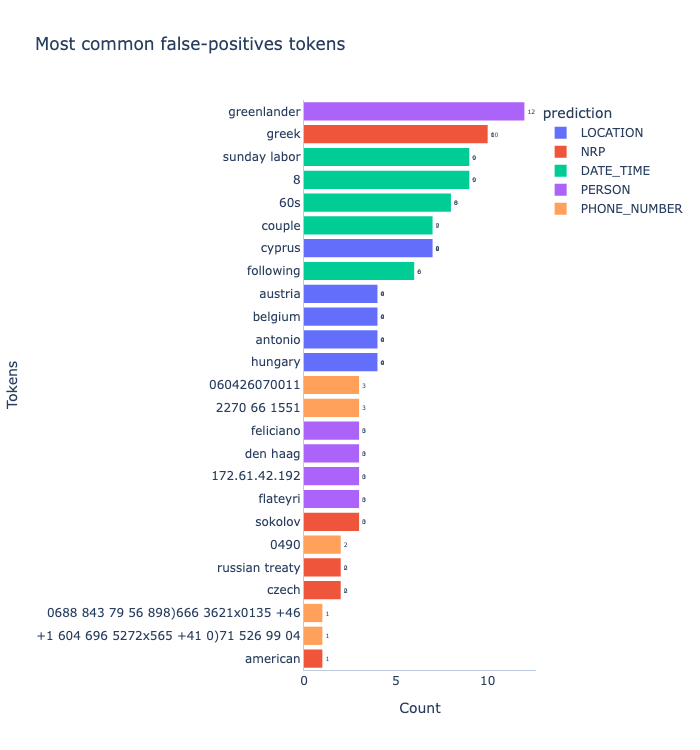

In [24]:
plotter.plot_most_common_tokens()

### 8a. False positives
#### Most common false positive tokens:

In [16]:
ModelError.most_common_fp_tokens(results.model_errors)

Most common false positive tokens:
[('8', 15),
 ('sunday labor', 13),
 ('greek', 10),
 ('60s', 8),
 ('greenlander', 8),
 ('couple', 7),
 ('10th', 7),
 ('cyprus', 7),
 ('following', 6),
 ('hungary', 4)]
---------------
Example sentence with each FP token:
	- 8 + years (`8` pred as DATE_TIME)
	- the last Sunday before Labor Day (`sunday labor` pred as DATE_TIME)
	- Greek (`greek` pred as NRP)
	- the 60s (`60s` pred as DATE_TIME)
	- Greenlander (`greenlander` pred as PERSON)
	- a couple of months (`couple` pred as DATE_TIME)
	- 10th year (`10th` pred as DATE_TIME)
	- Cyprus (`cyprus` pred as LOCATION)
	- the following year (`following` pred as DATE_TIME)
	- Hungary (`hungary` pred as LOCATION)


[('8', 15),
 ('sunday labor', 13),
 ('greek', 10),
 ('60s', 8),
 ('greenlander', 8),
 ('couple', 7),
 ('10th', 7),
 ('cyprus', 7),
 ('following', 6),
 ('hungary', 4)]

#### More FP analysis

In [17]:
# Get false positives for PERSON entity
fps_df = ModelError.get_fps_dataframe(results.model_errors, entity="PERSON")
fps_df[["full_text", "token", "annotation", "prediction"]].head(20)

,full_text,token,annotation,prediction
0,J Gelencsér ג€,j gelencsér ג€,O,PERSON
1,"Answer:""Tube Snake Boogie","answer:""tube snake boogie",O,PERSON
2,Faina D. Yefremova 's,faina d. yefremova,O,PERSON
3,Sara Schwarz \n,sara schwarz \n,O,PERSON
4,Nicole Mary John,nicole mary john,O,PERSON
5,Cettina Fanucci,cettina fanucci,O,PERSON
6,Berta Szöllössy,berta szöllössy,O,PERSON
7,Rua,rua,O,PERSON
8,Verdafero Eklund Michael Hodge,verdafero eklund michael hodge,O,PERSON
9,Király u.,király u.,O,PERSON


### 8b. False negatives (FN)

#### Most common false negative examples (should be predicted as entity but wasn't):

In [18]:
ModelError.most_common_fn_tokens(results.model_errors, n=15)

Most common false negative tokens:
[('greenlander', 11),
 ('english', 3),
 ('selma', 3),
 ('brazil', 3),
 ('tunisia', 2),
 ('2270 66 1551', 2),
 ('canada', 2),
 ('flateyri', 2),
 ('60', 2),
 ('17151 2450 crown', 2),
 ('2623322164608847', 2),
 ('213176828496175', 2),
 ('41086 kiannonkatu 98 464 oulu finland 80896', 2),
 ('joaquin suarez 2906', 2),
 ('hanne ul więckowskiego stefana 28', 2)]
---------------
Example sentence with each FN token:
	- Greenlander (`greenlander` annotated as LOCATION)
	- English (`english` annotated as NRP)
	- Selma (`selma` annotated as PERSON)
	- Brazil (`brazil` annotated as NRP)
	- Tunisia (`tunisia` annotated as LOCATION)
	- 2270 - 66 - 1551 (`2270 66 1551` annotated as US_DRIVER_LICENSE)
	- Canada (`canada` annotated as LOCATION)
	- Flateyri (`flateyri` annotated as LOCATION)
	- 60 (`60` annotated as DATE_TIME)
	- 17151 2450 Crown St (`17151 2450 crown` annotated as LOCATION)
	- 2623322164608847 (`2623322164608847` annotated as CREDIT_CARD)
	- 21317682849

[('greenlander', 11),
 ('english', 3),
 ('selma', 3),
 ('brazil', 3),
 ('tunisia', 2),
 ('2270 66 1551', 2),
 ('canada', 2),
 ('flateyri', 2),
 ('60', 2),
 ('17151 2450 crown', 2),
 ('2623322164608847', 2),
 ('213176828496175', 2),
 ('41086 kiannonkatu 98 464 oulu finland 80896', 2),
 ('joaquin suarez 2906', 2),
 ('hanne ul więckowskiego stefana 28', 2)]

#### More FN analysis

In [19]:
# Get false negatives for PHONE_NUMBER entity
fns_df = ModelError.get_fns_dataframe(results.model_errors, entity="PHONE_NUMBER")

In [20]:
fns_df[["full_text", "token", "annotation", "prediction"]].head(20)

,full_text,token,annotation,prediction
0,60 - 56 - 85 - 91,60 56 85 91,PHONE_NUMBER,O
1,( 37 ) 788 - 063 063 966,37 788 063 063 966,PHONE_NUMBER,O
2,0490 75 40 81,0490 75 40 81,PHONE_NUMBER,O
3,0494 92 82 32,0494 92 82 32,PHONE_NUMBER,O
4,699 956 915,699 956 915,PHONE_NUMBER,O
5,( 99 ) 645 - 791,99 645 791,PHONE_NUMBER,O
6,467 3395,467 3395,PHONE_NUMBER,O
7,78 651 450,78 651 450,PHONE_NUMBER,O
8,416 60 039 +46 ( 0)8 928 571 38 +1 - 984 - 182 - 0190,416 60 039 +46 0)8 928 571 38 +1 984 182 0190,PHONE_NUMBER,O
9,0688 872 49 99,0688 872 49 99,PHONE_NUMBER,O
